In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from drone_dataset import load_data_and_splits, DroneRFDataset
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Koristimo uređaj: {device}")

                                            
data, train_indices, val_indices, test_indices = load_data_and_splits()

val_dataset = DroneRFDataset(data, val_indices)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

Koristimo uređaj: cuda


In [2]:
                                                                  
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


                                                              
class ConfigurableCNN(nn.Module):
    def __init__(self, num_conv_layers=3, base_filters=16, dropout_rate=0.3, num_classes=7):
        super().__init__()
        self.conv_layers = nn.ModuleList()
        in_channels = 2
        current_filters = base_filters
        for i in range(num_conv_layers):
            self.conv_layers.append(nn.Conv2d(in_channels, current_filters, kernel_size=3, padding=1))
            in_channels = current_filters
            current_filters = current_filters * 2
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        final_spatial_size = 128 // (2 ** num_conv_layers)
        flattened_size = in_channels * final_spatial_size * final_spatial_size
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flattened_size, 128)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        for conv in self.conv_layers:
            x = self.pool(self.relu(conv(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [3]:
                
baseline_model = BaselineCNN(num_classes=7).to(device)
baseline_model.load_state_dict(torch.load('baseline_model.pth', weights_only=True))
baseline_model.eval()

                                                                                  
with open('automl_best_params.json', 'r') as f:
    best_params = json.load(f)

automl_model = ConfigurableCNN(
    num_conv_layers=best_params['num_conv_layers'],
    base_filters=best_params['base_filters'],
    dropout_rate=best_params['dropout_rate']
).to(device)
automl_model.load_state_dict(torch.load('automl_model.pth', weights_only=True))
automl_model.eval()

print("Oba modela uspešno učitana.")

Oba modela uspešno učitana.


In [4]:
from sklearn.metrics import classification_report, f1_score, recall_score, accuracy_score

                                                                         
                                                                      
                                          

all_true_labels = []
all_baseline_preds = []
all_automl_preds = []

with torch.no_grad():
    for batch_specs, batch_labels in val_loader:
        batch_specs = batch_specs.to(device)

                                    
        baseline_outputs = baseline_model(batch_specs)
        _, baseline_predicted = torch.max(baseline_outputs, dim=1)

                                  
        automl_outputs = automl_model(batch_specs)
        _, automl_predicted = torch.max(automl_outputs, dim=1)

        all_true_labels.extend(batch_labels.numpy())
        all_baseline_preds.extend(baseline_predicted.cpu().numpy())
        all_automl_preds.extend(automl_predicted.cpu().numpy())

                                                                                  
val_snr = data['snr'][val_indices].numpy()

class_names_list = ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']

print("Predikcije prikupljene za oba modela.")

Predikcije prikupljene za oba modela.


In [5]:
                                                             

summary_data = {
    'Metrika': ['Accuracy', 'Macro F1', 'Macro Recall', 'DJI Recall (najteža klasa)'],
    'Baseline': [
        accuracy_score(all_true_labels, all_baseline_preds),
        f1_score(all_true_labels, all_baseline_preds, average='macro'),
        recall_score(all_true_labels, all_baseline_preds, average='macro'),
        recall_score(all_true_labels, all_baseline_preds, average=None)[0]                  
    ],
    'AutoML': [
        accuracy_score(all_true_labels, all_automl_preds),
        f1_score(all_true_labels, all_automl_preds, average='macro'),
        recall_score(all_true_labels, all_automl_preds, average='macro'),
        recall_score(all_true_labels, all_automl_preds, average=None)[0]
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Razlika'] = summary_df['AutoML'] - summary_df['Baseline']

                                           
for col in ['Baseline', 'AutoML', 'Razlika']:
    summary_df[col] = summary_df[col].apply(lambda x: f"{x:.4f}")

print(summary_df.to_string(index=False))
summary_df.to_csv('final_comparison_summary.csv', index=False)

                   Metrika Baseline AutoML Razlika
                  Accuracy   0.9316 0.9406  0.0089
                  Macro F1   0.8894 0.9074  0.0180
              Macro Recall   0.8421 0.8721  0.0300
DJI Recall (najteža klasa)   0.6900 0.7781  0.0881


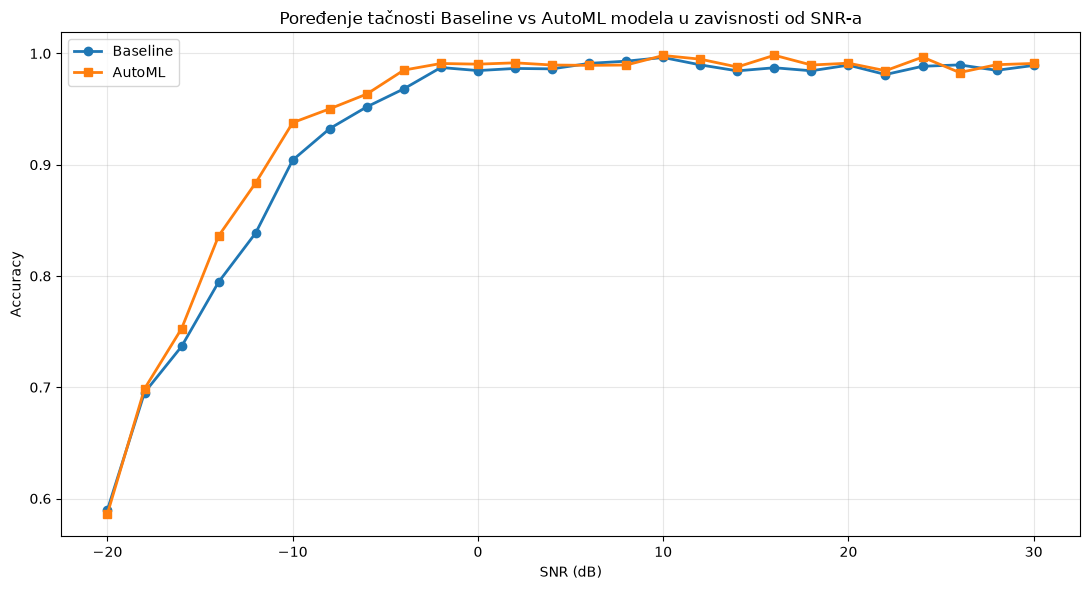

     baseline_acc  automl_acc
snr                          
-20      0.590018    0.586453
-18      0.695205    0.698630
-16      0.736655    0.752669
-14      0.794595    0.836036
-12      0.838649    0.883677
-10      0.904202    0.937815
-8       0.932504    0.950266
-6       0.952015    0.963532
-4       0.968224    0.985047
-2       0.987387    0.990991
 0       0.984615    0.990385
 2       0.986532    0.991582
 4       0.986159    0.989619
 6       0.991087    0.989305
 8       0.993068    0.989601
 10      0.996383    0.998192
 12      0.989744    0.994872
 14      0.984375    0.987847
 16      0.987159    0.998395
 18      0.984429    0.989619
 20      0.989510    0.991259
 22      0.981067    0.984509
 24      0.988487    0.996711
 26      0.989726    0.982877
 28      0.984848    0.989899
 30      0.989247    0.991039


In [6]:
                                                                       
results_df = pd.DataFrame({
    'true_label': all_true_labels,
    'baseline_pred': all_baseline_preds,
    'automl_pred': all_automl_preds,
    'snr': val_snr,
    'baseline_correct': np.array(all_baseline_preds) == np.array(all_true_labels),
    'automl_correct': np.array(all_automl_preds) == np.array(all_true_labels)
})

                                                                            
accuracy_by_snr = results_df.groupby('snr').agg(
    baseline_acc=('baseline_correct', 'mean'),
    automl_acc=('automl_correct', 'mean')
)

                                                                      
plt.figure(figsize=(11, 6))
plt.plot(accuracy_by_snr.index, accuracy_by_snr['baseline_acc'], marker='o', label='Baseline', linewidth=2)
plt.plot(accuracy_by_snr.index, accuracy_by_snr['automl_acc'], marker='s', label='AutoML', linewidth=2)
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Poređenje tačnosti Baseline vs AutoML modela u zavisnosti od SNR-a')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_accuracy_by_snr.png', dpi=150)
plt.show()

print(accuracy_by_snr)

In [7]:
                       

AutoML model (pronađen putem Optuna pretrage: 4 conv sloja, 32 base filtera, 
dropout 0.22, learning rate 0.0007) nadmašuje ručno dizajnirani baseline model 
po svim posmatranim metrikama:

- Accuracy: 93.16% → 94.06% (+0.89pp)
- Macro F1: 88.94% → 90.74% (+1.80pp)  
- Macro Recall: 84.21% → 87.21% (+3.00pp)
- DJI Recall (najteža klasa): 69.00% → 77.81% (+8.81pp)

Poboljšanje nije ravnomerno raspoređeno - najizraženije je kod SNR vrednosti 
između -20 i -6 dB (do 4.5pp razlike u accuracy), dok se kod visokih SNR 
vrednosti (>0dB) modeli praktično izjednačavaju usled ceiling efekta.

**Odabrani model za serviranje: AutoML model** (automl_model.pth), 
zbog konzistentno boljih performansi, posebno kod retkih klasa i teških 
(niskih SNR) uslova - scenario najbliži realnoj primeni.

SyntaxError: invalid character '→' (U+2192) (278398509.py, line 7)